# **Astronomical Object Classification: A Broad Cosmic Object Categorization**

**Context**

In astronomy, astronomical object classification refers to the process of classifying astronomical objects based on their observable properties. In this project, the objects are classified into three categories: stars, galaxies, and quasars. The classification of these objects is a fundamental task in modern astronomy. The early cataloguing of stars and their distribution across the sky contributed to our understanding of the Milky Way, while the recognition that the Andromeda Galaxy is a separate galaxy from our own led to the study and cataloguing of numerous galaxies as increasingly powerful telescopes were developed. This dataset aims to classify stars, galaxies, and quasars using their photometric and observational features.

**Content**

The data consists of 100,000 observations of space taken by the SDSS (Sloan Digital Sky Survey). Every observation is described by 17 feature columns and 1 class column which identifies it to be either a star, galaxy or quasar.

1. obj_ID = Object Identifier, the unique value that identifies the object in the image catalog used by the CAS
2. alpha = Right Ascension angle (at J2000 epoch)
3. delta = Declination angle (at J2000 epoch)
4. u = Ultraviolet filter in the photometric system
5. g = Green filter in the photometric system
6. r = Red filter in the photometric system
7. i = Near Infrared filter in the photometric system
8. z = Infrared filter in the photometric system
9. run_ID = Run Number used to identify the specific scan
10. rerun_ID = Rerun Number to specify how the image was processed
11. cam_col = Camera column to identify the scanline within the run
12. field_ID = Field number to identify each field
13. spec_obj_ID = Unique ID used for optical spectroscopic objects (this means that 2 different observations with the same spec_obj_ID must share the output class)
14. class = object class (galaxy, star or quasar object)
15. redshift = redshift value based on the increase in wavelength
16. plate = plate ID, identifies each plate in SDSS
17. MJD = Modified Julian Date, used to indicate when a given piece of SDSS data was taken
18. fiber_ID = fiber ID that identifies the fiber that pointed the light at the focal plane in each observation

**Citation**

fedesoriano. (January 2022). Stellar Classification Dataset - SDSS17. Retrieved [11 May 2026] from https://www.kaggle.com/fedesoriano/stellar-classification-dataset-sdss17.

**Acknowledgements**

The data released by the SDSS is under public domain. Its taken from the current data release RD17.

More information about the license: http://www.sdss.org/science/image-gallery/

**SDSS Publications:**

Abdurro’uf et al., The Seventeenth data release of the Sloan Digital Sky Surveys: Complete Release of MaNGA, MaStar and APOGEE-2 DATA (Abdurro’uf et al. submitted to ApJS) [arXiv:2112.02026]

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df1=pd.read_csv(r"C:\Users\omjit\Downloads\project\star_classification.csv")
df1

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1.237679e+18,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,7778,301,2,581,1.055431e+19,GALAXY,0.000000,9374,57749,438
99996,1.237679e+18,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,7917,301,1,289,8.586351e+18,GALAXY,0.404895,7626,56934,866
99997,1.237668e+18,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,5314,301,4,308,3.112008e+18,GALAXY,0.143366,2764,54535,74
99998,1.237661e+18,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,3650,301,4,131,7.601080e+18,GALAXY,0.455040,6751,56368,470


# **Step 1 - Exploratory Data Analysis (EDA) and Data Visualization**

In [8]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7), str(1)
mem

In [9]:
df1.nunique()

obj_ID          78053
alpha           99999
delta           99999
u               93748
g               92651
r               91901
i               92019
z               92007
run_ID            430
rerun_ID            1
cam_col             6
field_ID          856
spec_obj_ID    100000
class               3
redshift        99295
plate            6284
MJD              2180
fiber_ID         1000
dtype: int64

In [10]:
df1.describe()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


## Visualizing Outliers (Before Removal)

Before proceeding with outlier removal, let's visualize the distribution of our numerical features using box plots. This will help us identify extreme values and understand their extent in the dataset.

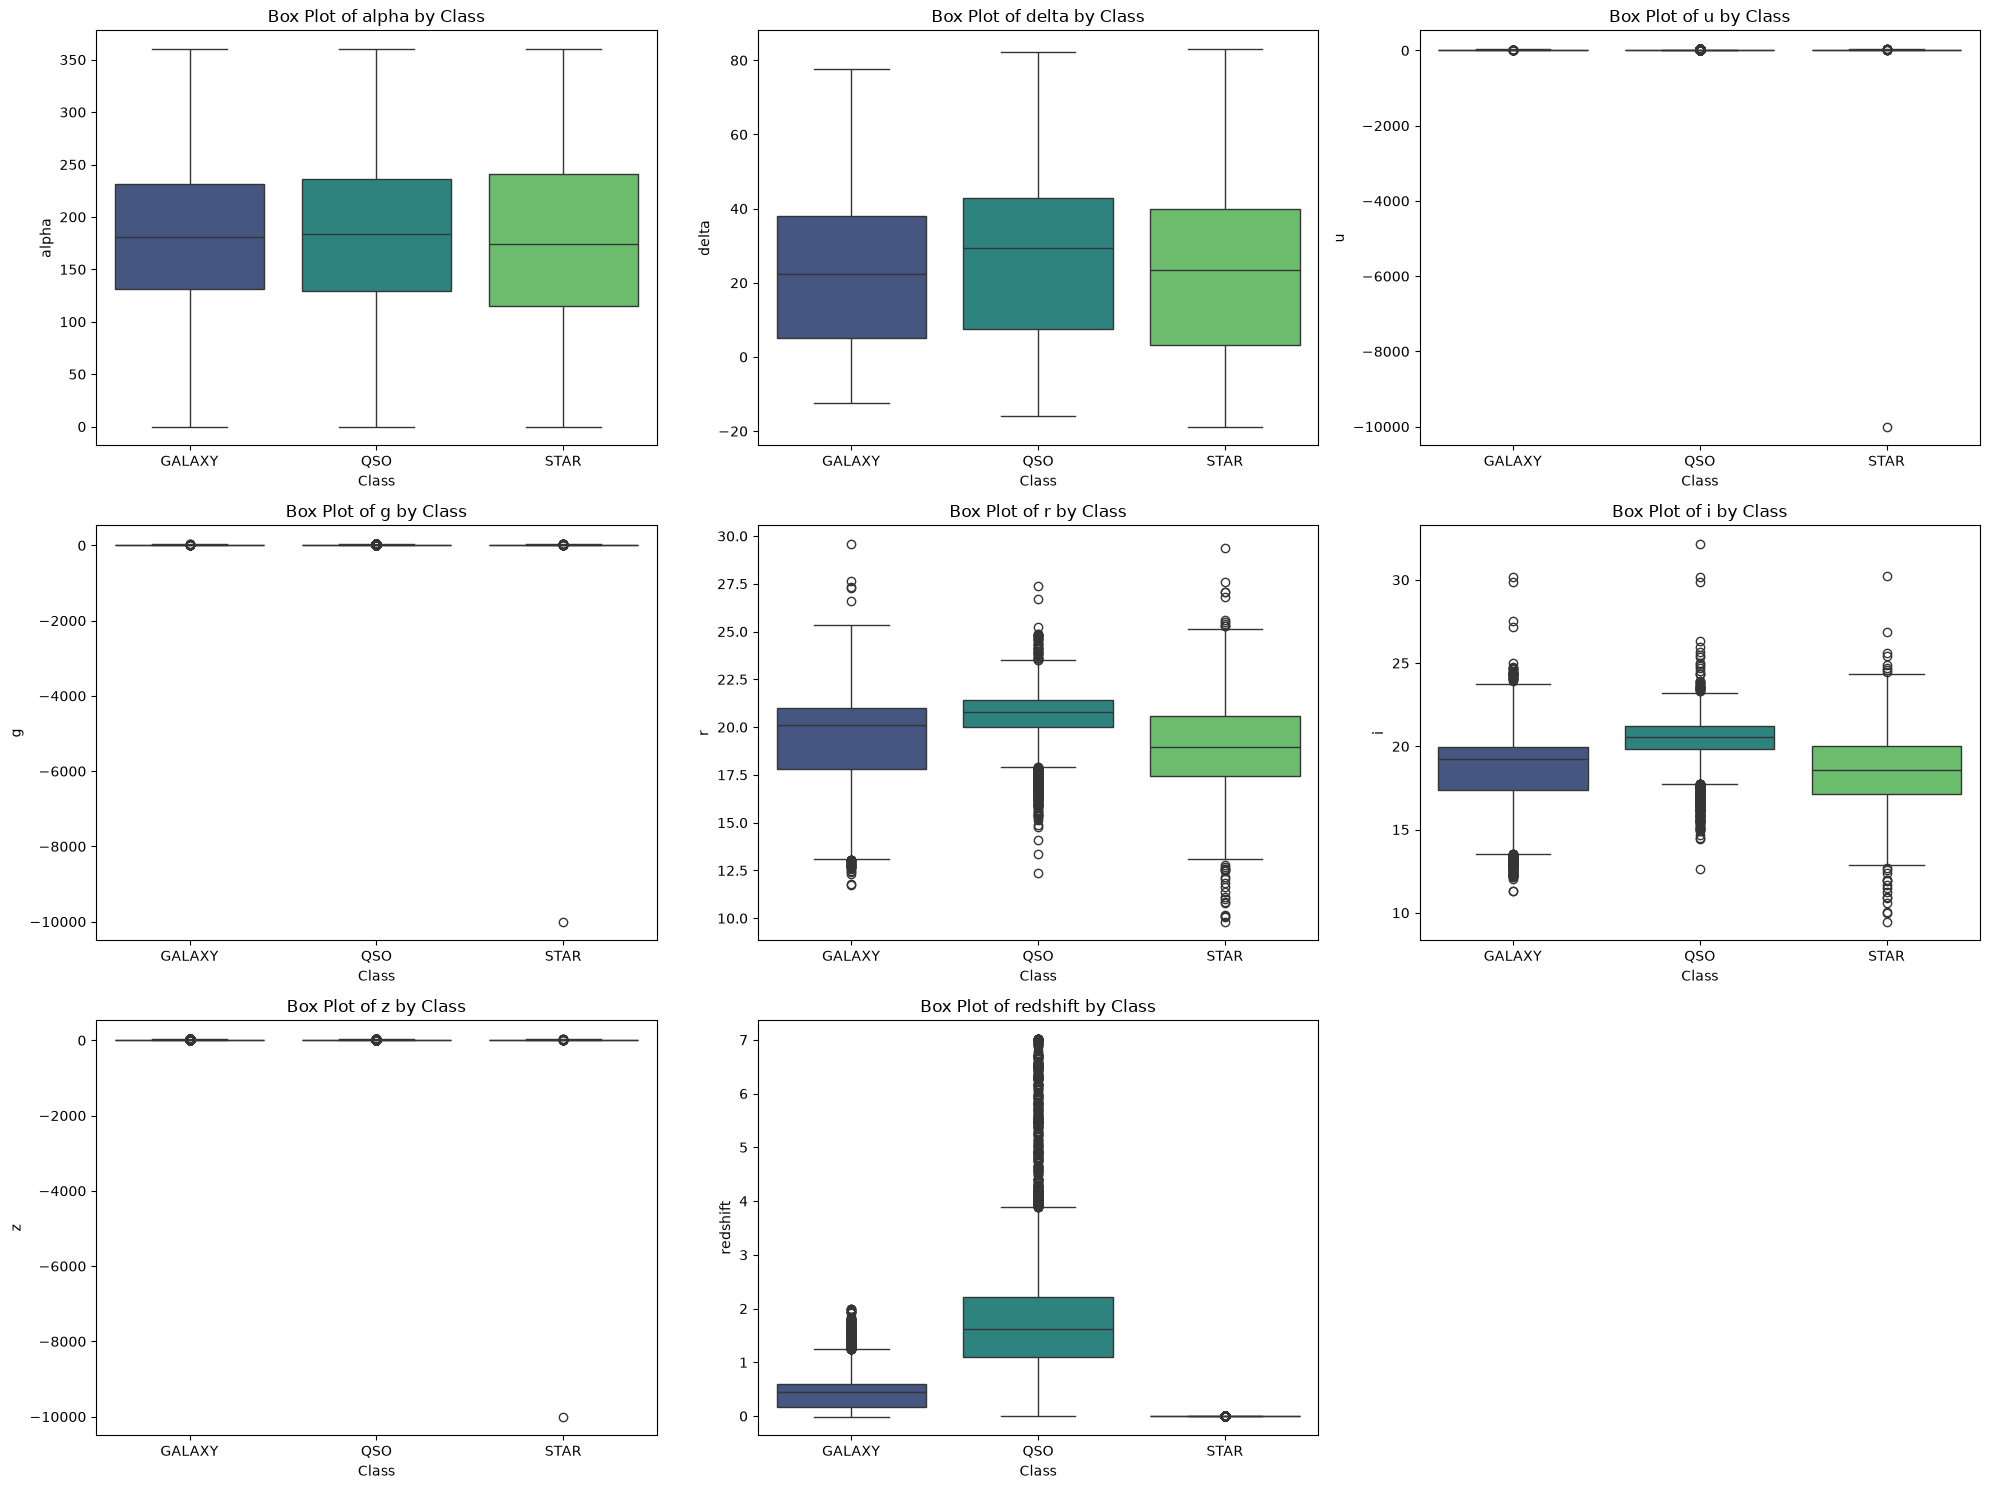

The box plots above show the distribution of numerical features across different stellar classes and highlight potential outliers.


In [11]:
numerical_features_for_plotting = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

# Create box plots for each numerical feature, differentiated by class
plt.figure(figsize=(20, 15)) # Increased figure size to accommodate more detailed plots
num_cols = len(numerical_features_for_plotting)
num_rows = (num_cols + 2) // 3 # Calculate rows needed for a 3-column layout

for i, column in enumerate(numerical_features_for_plotting):
    plt.subplot(num_rows, 3, i + 1) # Arrange plots in a dynamic grid (e.g., 3 columns)
    sns.boxplot(x='class', y=column, data=df1, palette='viridis', hue='class', legend=False)
    plt.title(f'Box Plot of {column} by Class')
    plt.xlabel('Class')
    plt.ylabel(column)
plt.tight_layout()
plt.show()

print("The box plots above show the distribution of numerical features across different stellar classes and highlight potential outliers.")

## Outlier Detection and Handling

Based on the `df1.describe()` output, some photometric bands (`u`, `g`, `z`) contain ` -9999` values, which are clearly erroneous and need to be handled. After addressing these, we will use the Local Outlier Factor (LOF) method to identify and remove other potential outliers from the numerical features. This ensures a cleaner dataset for further analysis and model training.

LOF has two purposes:

* **Exploratory data cleaning/visualization:** identify extremely anomalous observations that dominate the scale of the plots.

* **Outlier Detection:** After replacing invalid -9999 values, several extreme observations remained. These observations produced unusually large feature values and caused the scale of the scatter plots to be dominated by a small number of points, making the main distribution difficult to visualize. Local Outlier Factor (LOF) was therefore used to identify highly anomalous observations and obtain a cleaner dataset for exploratory visualization and subsequent analysis.

In [12]:
# Replace -9999 values with NaN and drop rows with these erroneous entries
# These -9999.0 values are sentinel values representing missing or clearly erroneous data points,
# not statistical outliers that LOF is designed to detect. Removing them upfront is a crucial data cleaning step.
print(f"Initial number of rows: {len(df1)}")

for col in ['u', 'g', 'z']:
    if (df1[col] == -9999.0).any():
        df1[col] = df1[col].replace(-9999.0, np.nan)

# Drop rows where any of the specified columns have NaN values now
df1.dropna(subset=['u', 'g', 'z'], inplace=True)

print(f"Number of rows after removing -9999 values: {len(df1)}")

Initial number of rows: 100000
Number of rows after removing -9999 values: 99999


In [13]:
from sklearn.neighbors import LocalOutlierFactor

# Define numerical features for LOF-based outlier detection
# These are the same features used for model training later, plus other relevant numerical ones.
# 'obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'plate', 'MJD', 'fiber_ID' are identifiers or categorical-like and usually not subject to outlier removal in this context.

numerical_features_for_outliers = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
X_lof = df1[numerical_features_for_outliers]

initial_rows = df1.shape[0]
print(f"Number of rows before LOF outlier removal: {initial_rows}")

# Initialize and fit the Local Outlier Factor model
# novelty=False means the LOF model is used for outlier detection (fit_predict) on the training data itself.
# The n_neighbors parameter can be tuned.
lof = LocalOutlierFactor(n_neighbors=20, contamination='auto') # 'auto' uses the default threshold from the original LOF formulation

# Fit the model and predict outlier scores
# -1 for outliers, 1 for inliers
y_pred_lof = lof.fit_predict(X_lof)

# Filter out the outliers (rows where y_pred_lof is -1)
outlier_mask = (y_pred_lof == 1)
df1 = df1[outlier_mask].copy() # Explicitly create a copy to prevent SettingWithCopyWarning

# Reset index after dropping rows
df1.reset_index(drop=True, inplace=True)

rows_after_outlier_removal = df1.shape[0]
print(f"Number of rows after LOF outlier removal: {rows_after_outlier_removal}")
print(f"Total rows removed: {initial_rows - rows_after_outlier_removal}")

df1.describe()

Number of rows before LOF outlier removal: 99999
Number of rows after LOF outlier removal: 98596
Total rows removed: 1403


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,9.859600e+04,98596.000000,98596.000000,98596.000000,98596.000000,98596.000000,98596.000000,98596.000000,98596.000000,98596.0,98596.000000,98596.000000,9.859600e+04,98596.000000,98596.000000,98596.000000,98596.000000
mean,1.237665e+18,177.641931,24.177615,22.080108,20.632660,19.645721,19.084433,18.766943,4482.102418,301.0,3.512201,186.224431,5.789077e+18,0.560543,5141.623129,55591.579070,449.503276
std,8.441491e+12,96.511729,19.628838,2.228537,2.007693,1.823262,1.729235,1.737555,1965.447078,0.0,1.586290,149.028752,3.320744e+18,0.670156,2949.397126,1806.797759,272.541823
min,1.237646e+18,0.005528,-17.636198,14.971550,13.874320,13.019290,12.598500,12.279380,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.609540,5.218739,20.355902,18.971340,18.143633,17.738375,17.465005,3185.000000,301.0,2.000000,82.000000,2.846433e+18,0.058097,2528.000000,54241.000000,221.000000
50%,1.237663e+18,180.976497,23.717142,22.171350,21.098825,20.123710,19.401175,19.001700,4188.000000,301.0,4.000000,146.000000,5.622972e+18,0.425443,4994.000000,55883.000000,433.000000
75%,1.237668e+18,233.808897,39.935943,23.666235,22.120015,21.036325,20.385960,19.913380,5326.000000,301.0,5.000000,241.000000,8.332812e+18,0.699129,7401.000000,56777.000000,645.000000
max,1.237681e+18,359.999810,79.343076,29.186370,27.210410,24.991640,24.673550,24.393310,8162.000000,301.0,6.000000,989.000000,1.412694e+19,6.450194,12547.000000,58932.000000,1000.000000


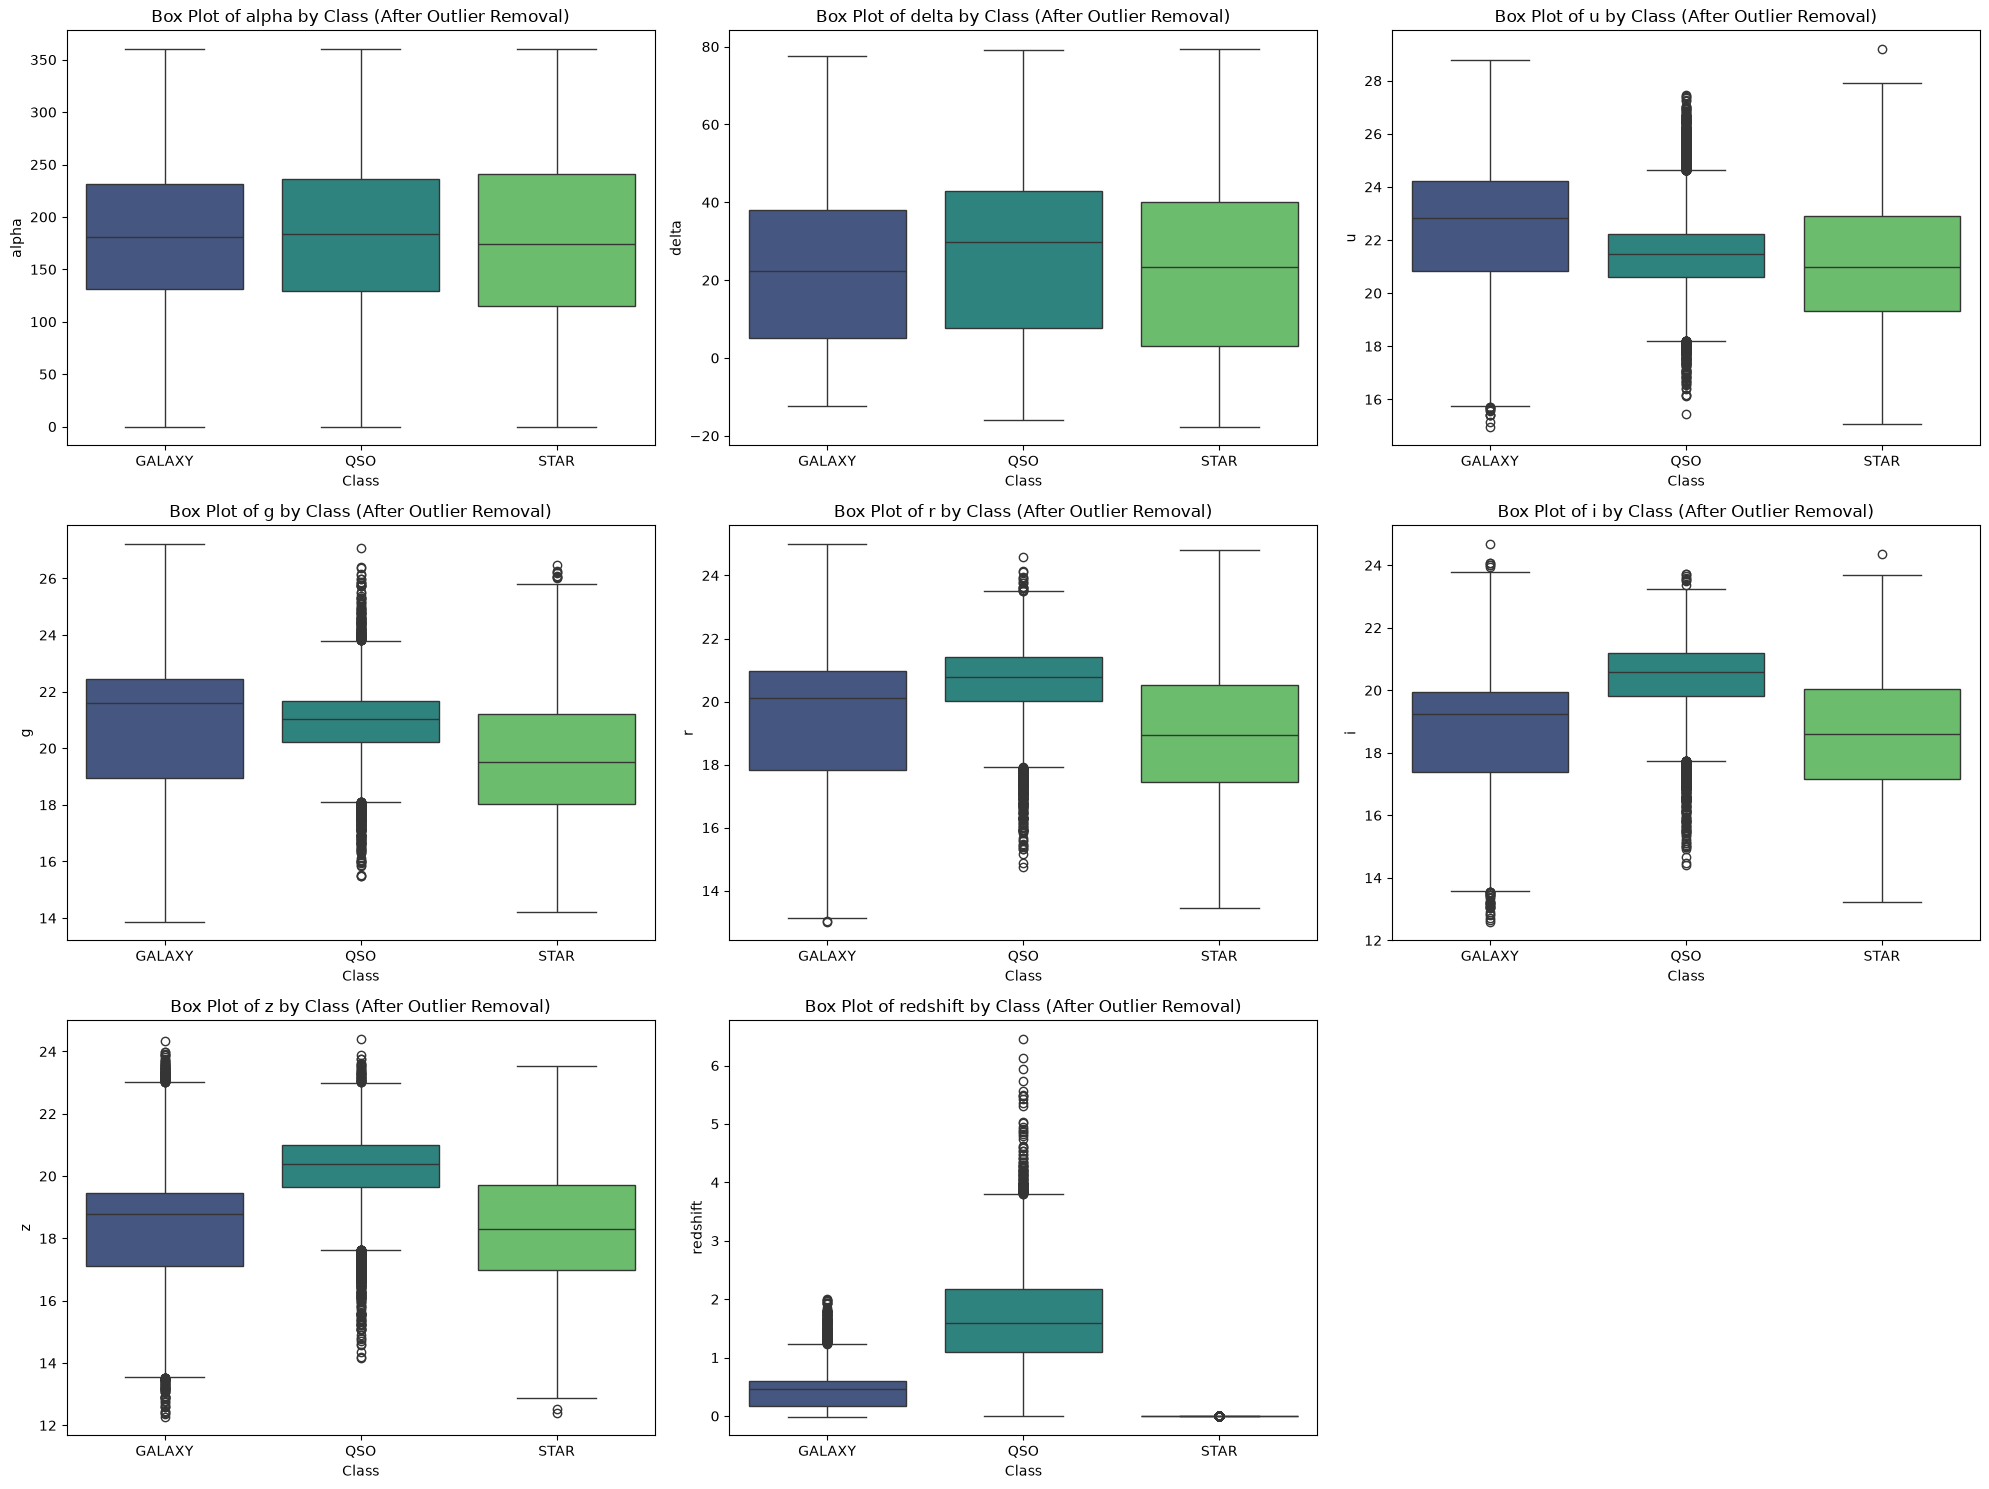

The box plots above show the distribution of numerical features across different stellar classes and highlight potential outliers, after LOF removal.


In [14]:
numerical_features_for_plotting = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

# Create box plots for each numerical feature, differentiated by class
plt.figure(figsize=(20, 15)) # Increased figure size to accommodate more detailed plots
num_cols = len(numerical_features_for_plotting)
num_rows = (num_cols + 2) // 3 # Calculate rows needed for a 3-column layout

for i, column in enumerate(numerical_features_for_plotting):
    plt.subplot(num_rows, 3, i + 1) # Arrange plots in a dynamic grid (e.g., 3 columns)
    sns.boxplot(x='class', y=column, data=df1, palette='viridis', hue='class', legend=False)
    plt.title(f'Box Plot of {column} by Class (After Outlier Removal)')
    plt.xlabel('Class')
    plt.ylabel(column)
plt.tight_layout()
plt.show()

print("The box plots above show the distribution of numerical features across different stellar classes and highlight potential outliers, after LOF removal.")

In [15]:
df1['class'].unique()

<ArrowStringArray>
['GALAXY', 'QSO', 'STAR']
Length: 3, dtype: str

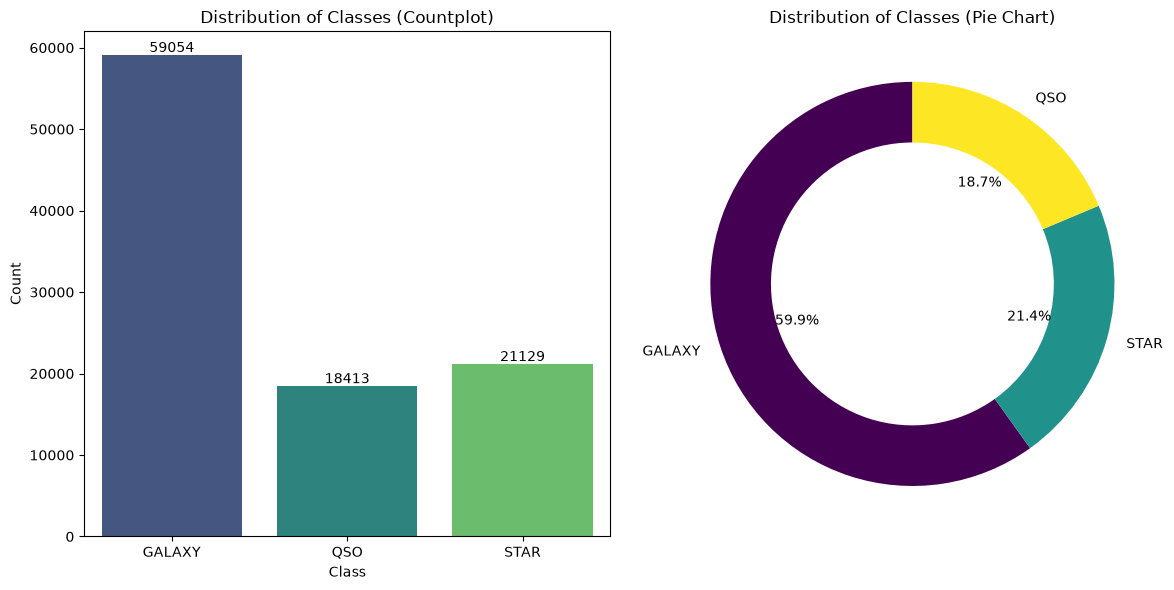

In [16]:
plt.figure(figsize=(12, 6))

# Subplot 1: Countplot
plt.subplot(1, 2, 1)
sns.countplot(x=df1['class'], hue=df1['class'], palette='viridis', legend=False)
plt.title('Distribution of Classes (Countplot)')
plt.xlabel('Class')
plt.ylabel('Count')

# Annotate countplot with actual counts
for container in plt.gca().containers:
    plt.bar_label(container)

# Subplot 2: Pie chart
plt.subplot(1, 2, 2)
df1['class'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis', wedgeprops=dict(width=0.3))
plt.title('Distribution of Classes (Pie Chart)')
plt.ylabel('') # Hide the y-label for better aesthetics

plt.tight_layout()
plt.show()

The class distribution is moderately imbalanced rather than severely imbalanced. Furthermore, the per-class precision, recall and F1-scores do not indicate a serious minority-class performance problem. Therefore, SMOTE was not considered necessary for this project.

## Step 2 — Correlation Analysis

First, let's examine the correlations between the numerical features in the dataset. A correlation matrix and heatmap will help us identify strong relationships.

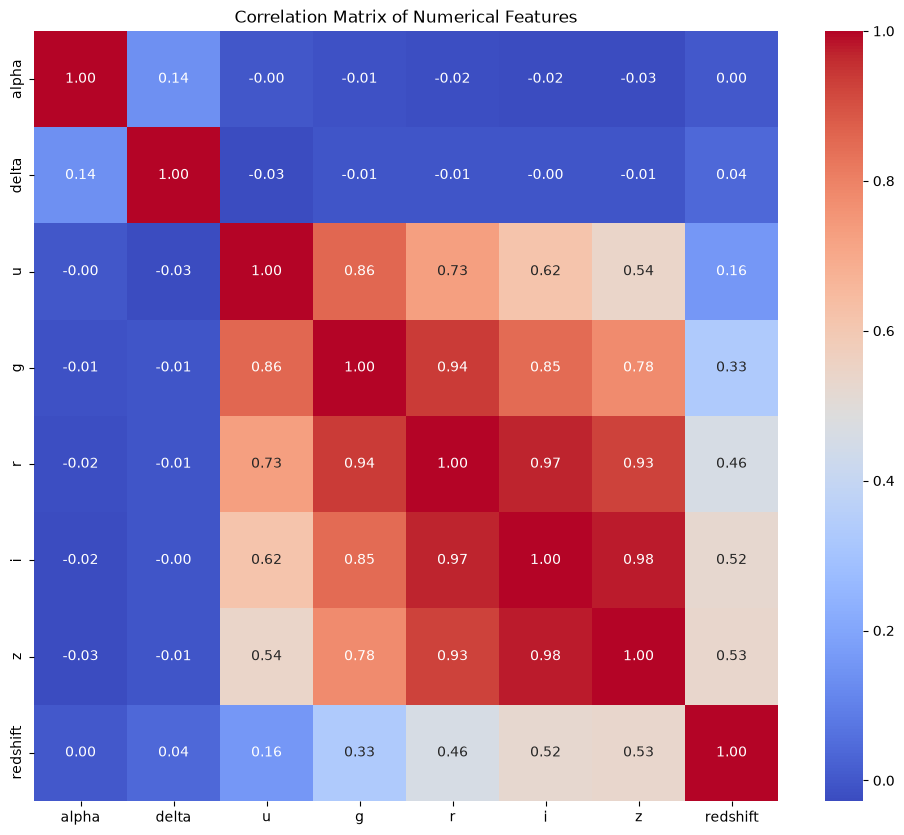

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for correlation analysis
# Exclude 'obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'plate', 'MJD', 'fiber_ID' as they are identifiers or specific observation details
numerical_cols = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
correlation_matrix = df1[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Scatter plots to visualize the relationships between specific features, for example 'Temperature vs Luminosity' (represented here by photometric bands).

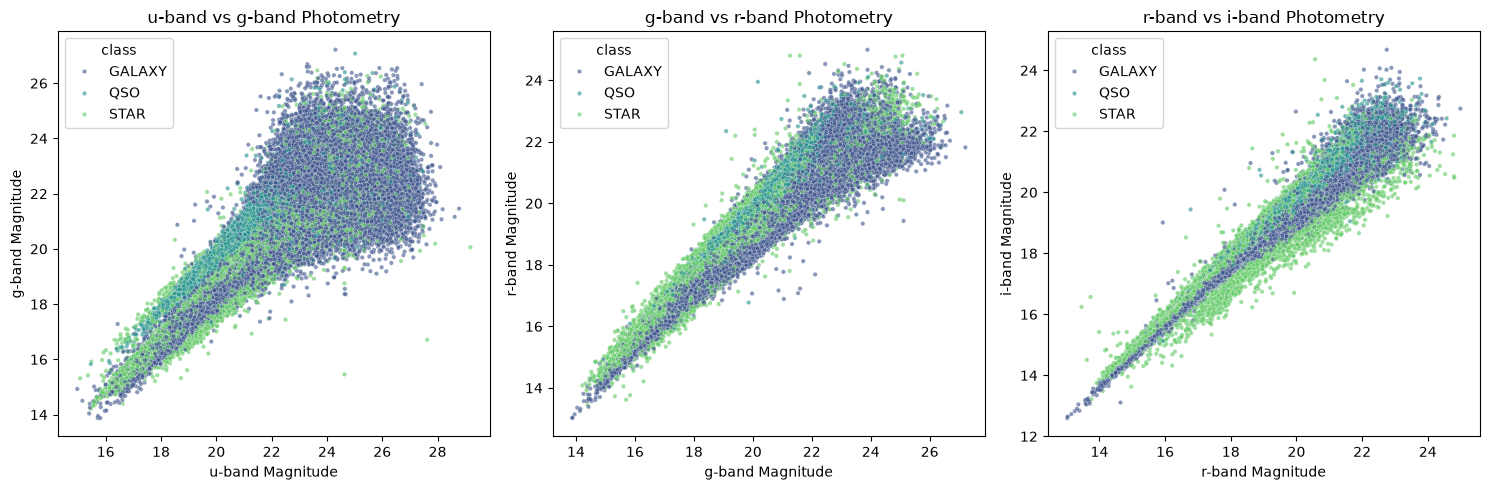

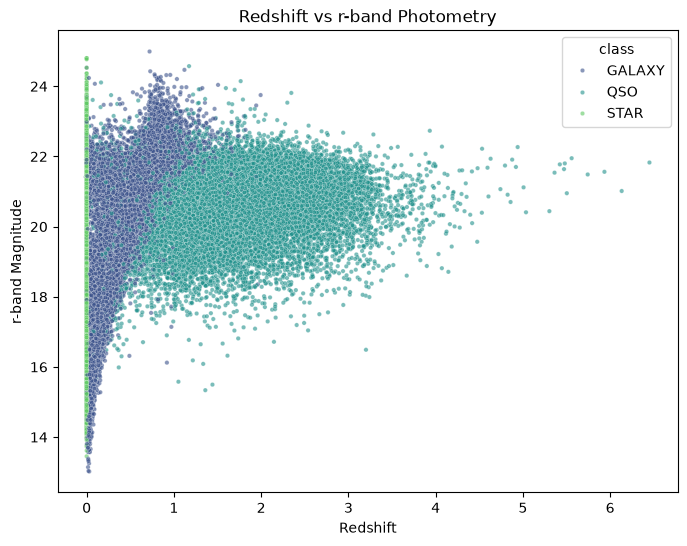

In [18]:
%matplotlib inline

# Scatter plots for selected photometric features

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='u', y='g', hue='class', data=df1, palette='viridis', alpha=0.6, s=10)
plt.title('u-band vs g-band Photometry')
plt.xlabel('u-band Magnitude')
plt.ylabel('g-band Magnitude')

plt.subplot(1, 3, 2)
sns.scatterplot(x='g', y='r', hue='class', data=df1, palette='viridis', alpha=0.6, s=10)
plt.title('g-band vs r-band Photometry')
plt.xlabel('g-band Magnitude')
plt.ylabel('r-band Magnitude')

plt.subplot(1, 3, 3)
sns.scatterplot(x='r', y='i', hue='class', data=df1, palette='viridis', alpha=0.6, s=10)
plt.title('r-band vs i-band Photometry')
plt.xlabel('r-band Magnitude')
plt.ylabel('i-band Magnitude')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x='redshift', y='r', hue='class', data=df1, palette='viridis', alpha=0.6, s=10)
plt.title('Redshift vs r-band Photometry')
plt.xlabel('Redshift')
plt.ylabel('r-band Magnitude')
plt.show()

## Step 3 — Clustering: K-Means Clustering

Now, let's apply K-Means clustering to automatically group stars based on their properties. We will first select relevant features for clustering, then apply K-Means, and finally, try to compare the created clusters with the actual `class` labels. K-Means is used here as an exploratory unsupervised-learning exercise to investigate whether the STAR population contains naturally separated groups in feature space. The dataset does not provide labels for stellar subtypes, so the clusters cannot be directly interpreted as physical stellar subclasses.

k = 2, silhouette score = 0.3439
k = 3, silhouette score = 0.2161
k = 4, silhouette score = 0.2180
k = 5, silhouette score = 0.1948
k = 6, silhouette score = 0.2035
k = 7, silhouette score = 0.1984
k = 8, silhouette score = 0.2037
k = 9, silhouette score = 0.1970

Best k = 2
Best silhouette score = 0.3439

K-Means clustering performed on 21129 stars with 2 clusters.

Count of stars per cluster:
cluster
0    10708
1    10421
Name: count, dtype: int64


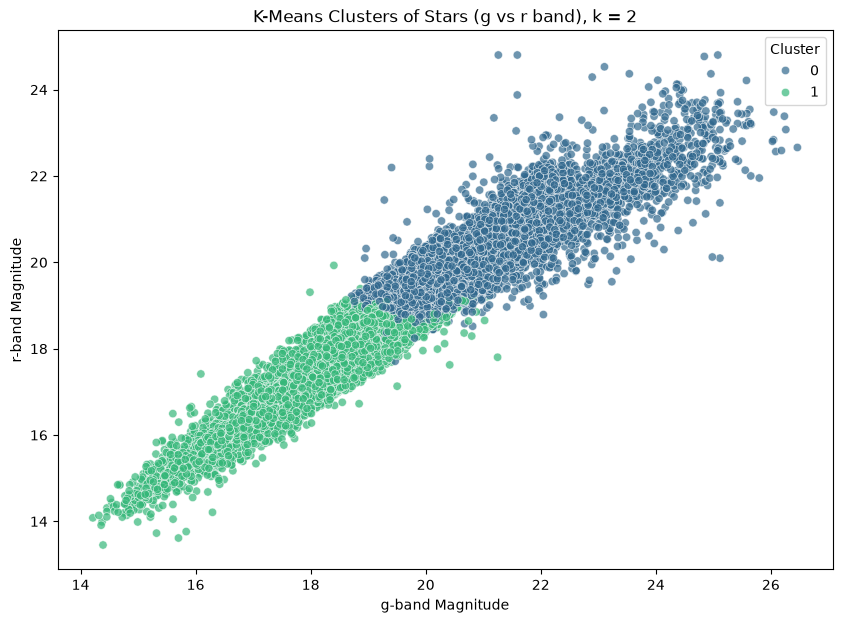

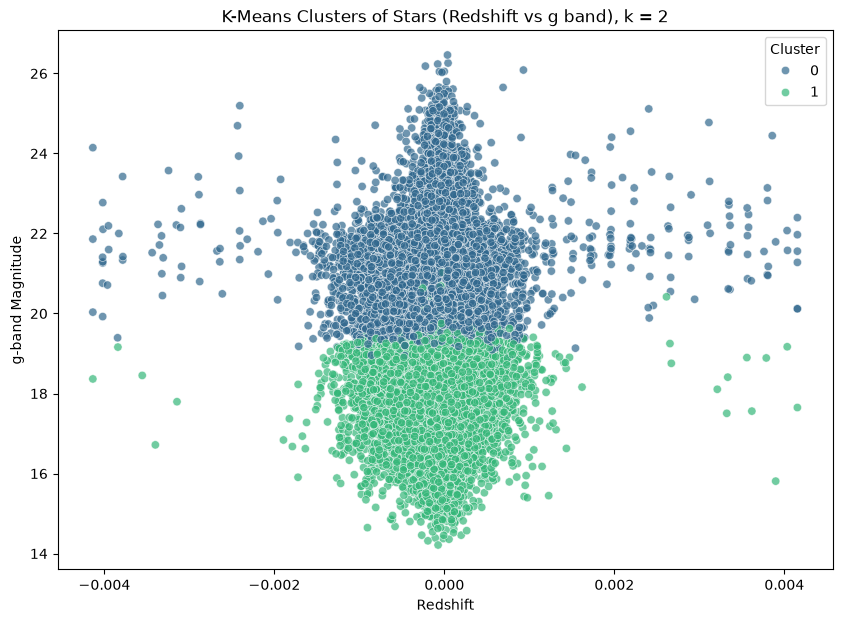

In [19]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Filter df1 to include only 'STAR' class for clustering
stars_df = df1[df1['class'] == 'STAR'].copy()

# Select features for clustering
clustering_features = ['u', 'g', 'r', 'i', 'z', 'redshift', 'alpha', 'delta']
X_stars = stars_df[clustering_features]

# Standardize the features before applying K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_stars)

# Test different numbers of clusters using silhouette score
silhouette_scores = {}

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores[k] = score

    print(f"k = {k}, silhouette score = {score:.4f}")

# Automatically select the k with the highest silhouette score
best_k = max(silhouette_scores, key=silhouette_scores.get)
best_score = silhouette_scores[best_k]

print(f"\nBest k = {best_k}")
print(f"Best silhouette score = {best_score:.4f}")

# Perform final K-Means clustering using the automatically selected k
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)

stars_df['cluster'] = kmeans.fit_predict(X_scaled)

print(f"\nK-Means clustering performed on " f"{len(stars_df)} stars with {best_k} clusters.\n")

# Display the count of stars in each cluster
print("Count of stars per cluster:")
print(stars_df['cluster'].value_counts())

# Visualize the clusters: g vs r
plt.figure(figsize=(10, 7))

sns.scatterplot(x='g', y='r', hue='cluster', data=stars_df, palette='viridis', alpha=0.7)

plt.title(f'K-Means Clusters of Stars (g vs r band), k = {best_k}')
plt.xlabel('g-band Magnitude')
plt.ylabel('r-band Magnitude')
plt.legend(title='Cluster')
plt.show()

# Visualize the clusters: redshift vs g
plt.figure(figsize=(10, 7))

sns.scatterplot(x='redshift', y='g', hue='cluster', data=stars_df, palette='viridis', alpha=0.7)

plt.title(f'K-Means Clusters of Stars (Redshift vs g band), k = {best_k}')
plt.xlabel('Redshift')
plt.ylabel('g-band Magnitude')
plt.legend(title='Cluster')
plt.show()

### Evaluation of Clustering

Since the original dataset categorizes 'class' into 'STAR', 'GALAXY', and 'QUASAR', and we've already filtered for 'STAR' objects, there isn't a direct ground truth for *sub-types* of stars within this dataset to compare our K-Means clusters against using metrics like Adjusted Rand Index or Homogeneity. However, if we had a more granular 'star_type' column, we could use that for comparison.

## Step 4 — Train Models

Before training our models, we need to prepare the data. This involves:
1.  **Feature Selection:** Choosing the relevant columns that will serve as input for our models.
2.  **Target Variable Encoding:** Converting the categorical `class` column into numerical format, as machine learning models require numerical input.
3.  **Data Splitting:** Dividing the dataset into training and testing sets to evaluate model performance on unseen data.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Define features (X) and target (y)
# We selected the photometric measurements, sky coordinates, and redshift as physically meaningful numerical features for classification, while excluding identifiers and observational metadata.
features = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
X = df1[features]
y = df1['class']

# Encode the target variable 'class' (Star, Galaxy, Quasar) into numerical labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, stratify=y_encoded, random_state=42)

print(f"Original target classes: {label_encoder.classes_}")
print(f"Encoded target mapping: {list(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")
print(f"Shape of training features (X_train): {X_train.shape}")
print(f"Shape of testing features (X_test): {X_test.shape}")
print(f"Shape of training target (y_train): {y_train.shape}")
print(f"Shape of testing target (y_test): {y_test.shape}")

Original target classes: ['GALAXY' 'QSO' 'STAR']
Encoded target mapping: [('GALAXY', np.int64(0)), ('QSO', np.int64(1)), ('STAR', np.int64(2))]
Shape of training features (X_train): (69017, 8)
Shape of testing features (X_test): (29579, 8)
Shape of training target (y_train): (69017,)
Shape of testing target (y_test): (29579,)


### Model 1: Logistic Regression

Let's start by training a Logistic Regression model, a common and effective baseline for classification tasks.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Standardize the features for Logistic Regression --> mean=0 and std=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # not used fit_transform becuase test data must remain unseen.

''''If we fit test data separately:
--> model indirectly learns test statistics
--> evaluation becomes biased

This is called: Data Leakage'''

# Initialize and train the Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Logistic Regression Model Training Complete.")

Logistic Regression Model Training Complete.


### Model 2: Decision Tree

Now, let's train a Decision Tree Classifier. Decision trees are non-parametric supervised learning methods used for classification and regression. The goal is to create a model that predicts the value of a target variable by learning simple decision rules inferred from the data features.

In [22]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train the Decision Tree model
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_tree = decision_tree_model.predict(X_test)

print("Decision Tree Model Training Complete.")

Decision Tree Model Training Complete.


### Model 3: Random Forest

Finally, let's train a Random Forest Classifier. Random Forest is an ensemble learning method that operates by constructing a multitude of decision trees at training time and outputting the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees.

In [23]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_forest = random_forest_model.predict(X_test)

print("Random Forest Model Training Complete.")

Random Forest Model Training Complete.


## Step 5 — Compare Accuracy

Now that we have trained three different classification models, let's evaluate their performance on the test set using various metrics: accuracy score, confusion matrix, precision, and recall. This will help us understand which model performs best for this stellar classification task.

### Logistic Regression Performance

Logistic Regression Accuracy: 0.9580

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

      GALAXY       0.96      0.97      0.97     17716
         QSO       0.95      0.88      0.91      5524
        STAR       0.95      1.00      0.97      6339

    accuracy                           0.96     29579
   macro avg       0.95      0.95      0.95     29579
weighted avg       0.96      0.96      0.96     29579



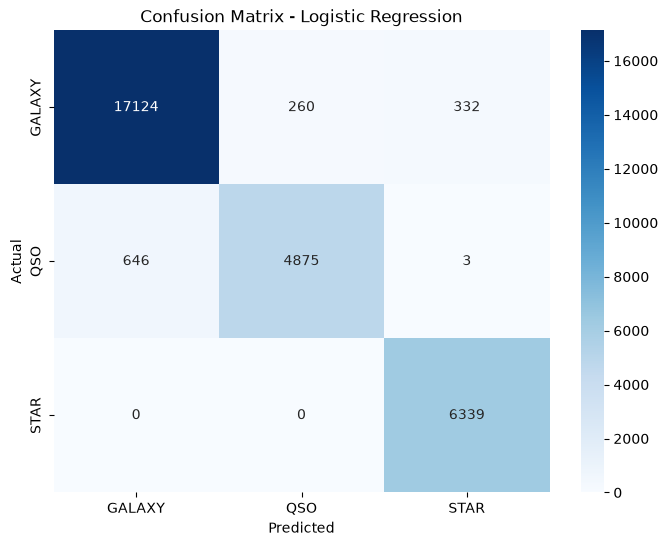

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluate Logistic Regression
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
print(f"Logistic Regression Accuracy: {accuracy_logistic:.4f}")
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_logistic, target_names=label_encoder.classes_))

# Confusion Matrix for Logistic Regression
cm_logistic = confusion_matrix(y_test, y_pred_logistic)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_logistic, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Decision Tree Performance

Decision Tree Accuracy: 0.9654

Classification Report (Decision Tree):
              precision    recall  f1-score   support

      GALAXY       0.97      0.97      0.97     17716
         QSO       0.91      0.91      0.91      5524
        STAR       1.00      1.00      1.00      6339

    accuracy                           0.97     29579
   macro avg       0.96      0.96      0.96     29579
weighted avg       0.97      0.97      0.97     29579



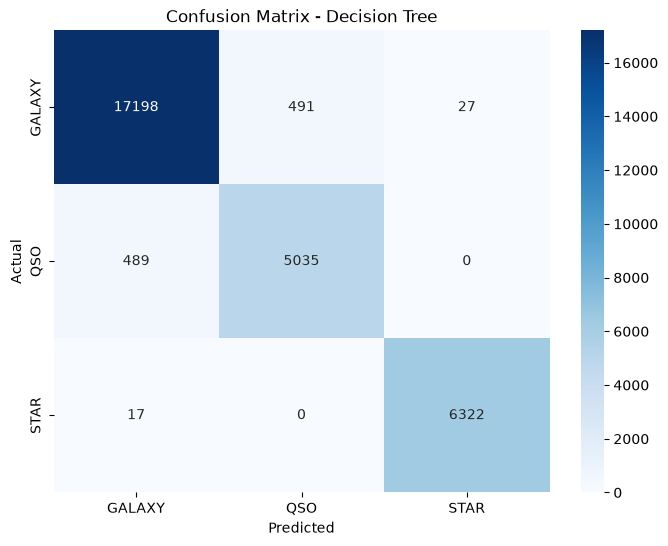

In [25]:
# Evaluate Decision Tree
accuracy_tree = accuracy_score(y_test, y_pred_tree)
print(f"Decision Tree Accuracy: {accuracy_tree:.4f}")
print("\nClassification Report (Decision Tree):")
print(classification_report(y_test, y_pred_tree, target_names=label_encoder.classes_))

# Confusion Matrix for Decision Tree
cm_tree = confusion_matrix(y_test, y_pred_tree)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Random Forest Performance

Random Forest Accuracy: 0.9791

Classification Report (Random Forest):
              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     17716
         QSO       0.97      0.93      0.95      5524
        STAR       0.99      1.00      1.00      6339

    accuracy                           0.98     29579
   macro avg       0.98      0.97      0.98     29579
weighted avg       0.98      0.98      0.98     29579



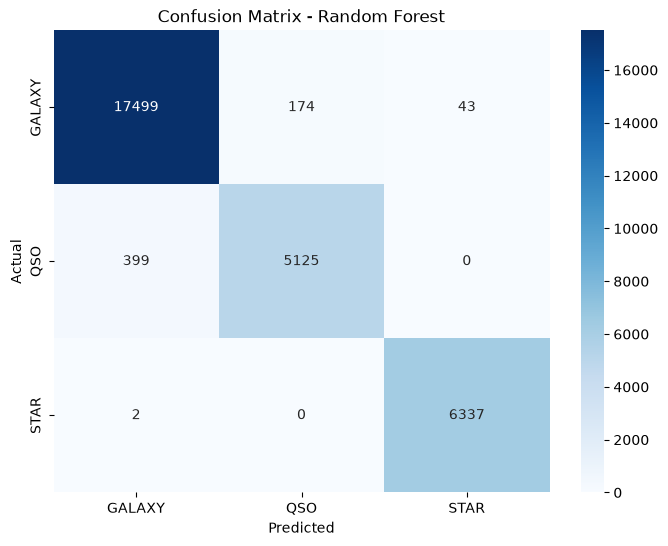

In [26]:
# Evaluate Random Forest
accuracy_forest = accuracy_score(y_test, y_pred_forest)
print(f"Random Forest Accuracy: {accuracy_forest:.4f}")
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_forest, target_names=label_encoder.classes_))

# Confusion Matrix for Random Forest
cm_forest = confusion_matrix(y_test, y_pred_forest)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_forest, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Step 6 — Feature Importance

One of the advantages of tree-based models like Random Forest is their ability to provide insights into feature importance. This step will help us understand which stellar properties contribute most to the classification of Stars, Galaxies, and Quasars.

Feature Importances from Random Forest Model:
    Feature  Importance
7  redshift    0.602427
6         z    0.086863
5         i    0.083058
3         g    0.076620
2         u    0.075570
4         r    0.044962
0     alpha    0.015598
1     delta    0.014901


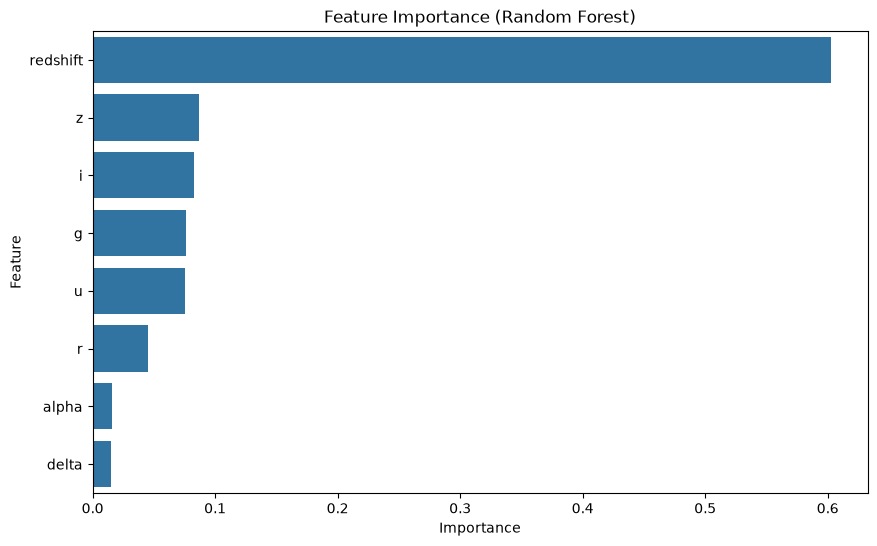

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the Random Forest model
feature_importances = random_forest_model.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
})

# Sort features by importance
features_df = features_df.sort_values(by='Importance', ascending=False)

print("Feature Importances from Random Forest Model:")
print(features_df)

# Visualize feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=features_df)
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

**Redshift had the highest impurity-based feature importance in the Random Forest model, indicating that the model relied heavily on redshift when distinguishing the three classes.**

## Step 7 — Learning Curves

Learning curves are plots that show the model's performance on the training set and validation set as a function of the number of training examples. They are useful for diagnosing whether a model suffers from high bias (underfitting) or high variance (overfitting).

*   **High Bias (Underfitting):** Both training and validation scores are low and converge to a similar low value. The model is too simple for the data.
*   **High Variance (Overfitting):** The training score is much higher than the validation score. The model is too complex and memorizing the training data.
*   **Good Fit:** Both training and validation scores are high and close to each other.

In [28]:
from sklearn.model_selection import learning_curve, StratifiedKFold

def plot_learning_curve(estimator, title, X, y, axes=None, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    if axes is None:
        _, axes = plt.subplots(1, 3, figsize=(20, 5))

    axes[0].set_title(title)
    if ylim is not None:
        axes[0].set_ylim(*ylim)
    axes[0].set_xlabel("Training examples")
    axes[0].set_ylabel("Score")

    (train_sizes, train_scores, test_scores, fit_times, _) = \
        learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs,
                       train_sizes=train_sizes, return_times=True)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    fit_times_mean = np.mean(fit_times, axis=1)
    fit_times_std = np.std(fit_times, axis=1)

    # Plot learning curve
    axes[0].grid()
    axes[0].fill_between(train_sizes, train_scores_mean - train_scores_std,
                         train_scores_mean + train_scores_std, alpha=0.1,
                         color="r")
    axes[0].fill_between(train_sizes, test_scores_mean - test_scores_std,
                         test_scores_mean + test_scores_std, alpha=0.1,
                         color="g")
    axes[0].plot(train_sizes, train_scores_mean, 'o-', color="r",
                 label="Training score")
    axes[0].plot(train_sizes, test_scores_mean, 'o-', color="g",
                 label="Cross-validation score")
    axes[0].legend(loc="best")

    # Plot n_samples vs fit_times
    axes[1].grid()
    axes[1].plot(train_sizes, fit_times_mean, 'o-')
    axes[1].fill_between(train_sizes, fit_times_mean - fit_times_std,
                         fit_times_mean + fit_times_std, alpha=0.1)
    axes[1].set_xlabel("Training examples")
    axes[1].set_ylabel("fit_times")
    axes[1].set_title("Scalability of the model")

    # Plot fit_times vs score
    axes[2].grid()
    axes[2].plot(fit_times_mean, test_scores_mean, 'o-')
    axes[2].fill_between(fit_times_mean, test_scores_mean - test_scores_std,
                         test_scores_mean + test_scores_std, alpha=0.1)
    axes[2].set_xlabel("fit_times")
    axes[2].set_ylabel("Score")
    axes[2].set_title("Performance of the model")

    return plt

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Learning Curve: Logistic Regression

For Logistic Regression, we use the scaled features (`X_train_scaled`). A significant gap between training and cross-validation scores suggests high variance (overfitting), while low scores for both indicate high bias (underfitting).

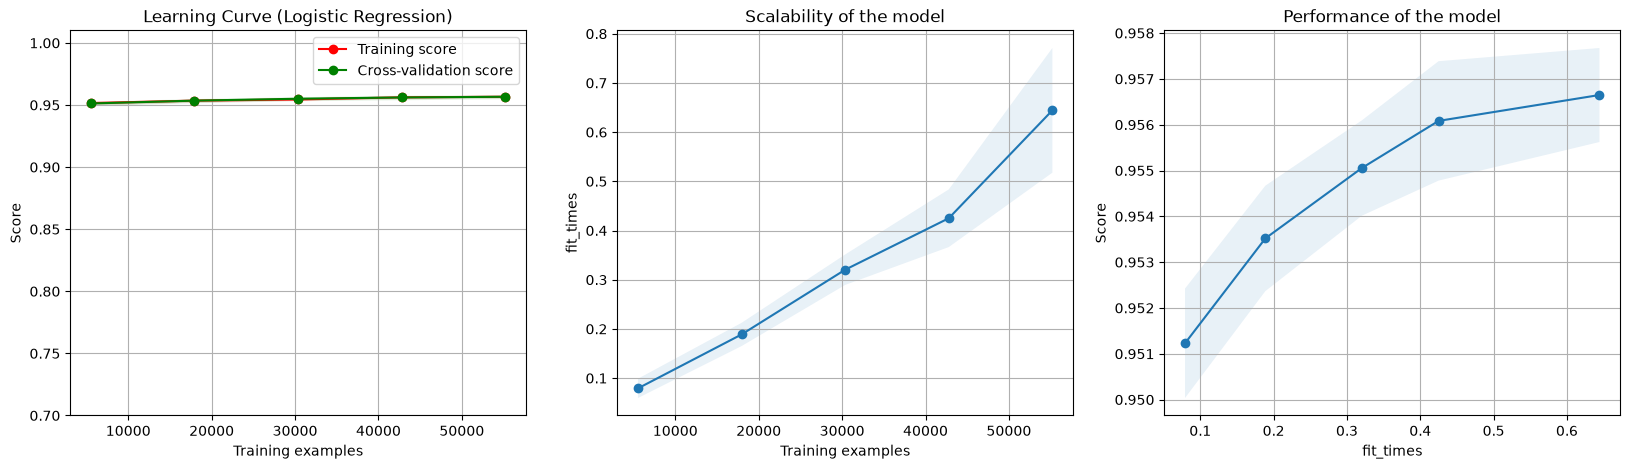

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

plot_learning_curve(logistic_model, "Learning Curve (Logistic Regression)", X_train_scaled, y_train,
                    axes=axes, ylim=(0.7, 1.01), cv=cv, n_jobs=4)

plt.show()

### Learning Curve: Decision Tree

Decision Trees are prone to overfitting. The learning curve will help us see if the model is too complex for the given data, leading to a large gap between training and validation scores.

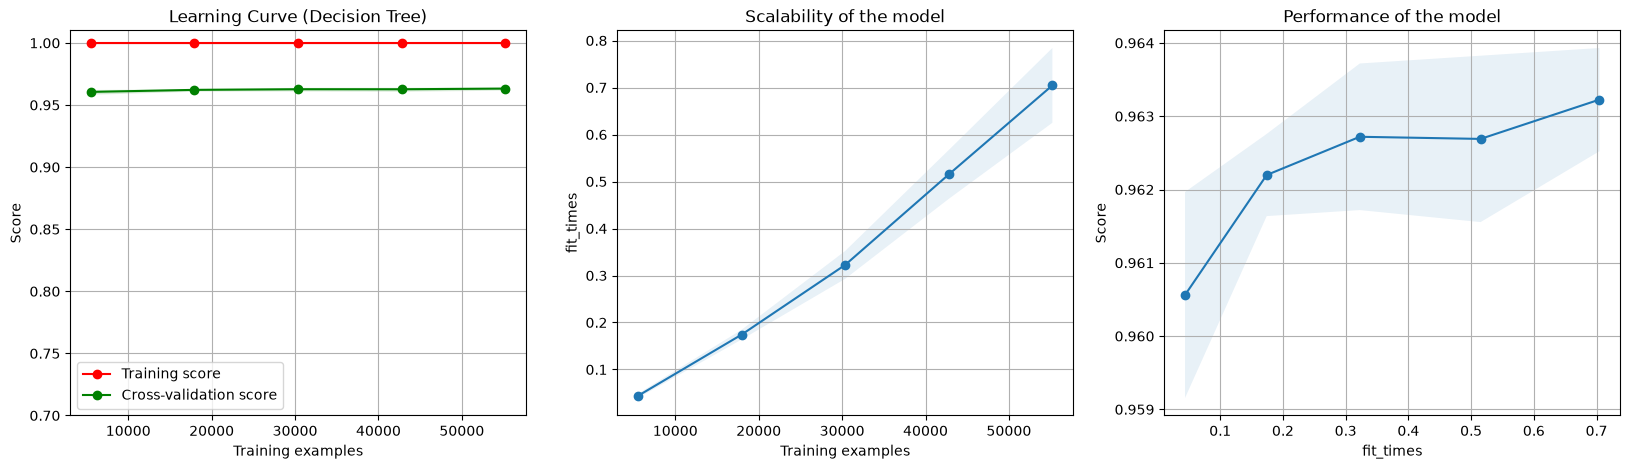

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

plot_learning_curve(decision_tree_model, "Learning Curve (Decision Tree)", X_train, y_train,
                    axes=axes, ylim=(0.7, 1.01), cv=cv, n_jobs=4)

plt.show()

### Learning Curve: Random Forest

Random Forests are ensemble models that typically show good generalization. We expect to see high scores for both training and cross-validation, with a relatively small gap, indicating a good balance between bias and variance.

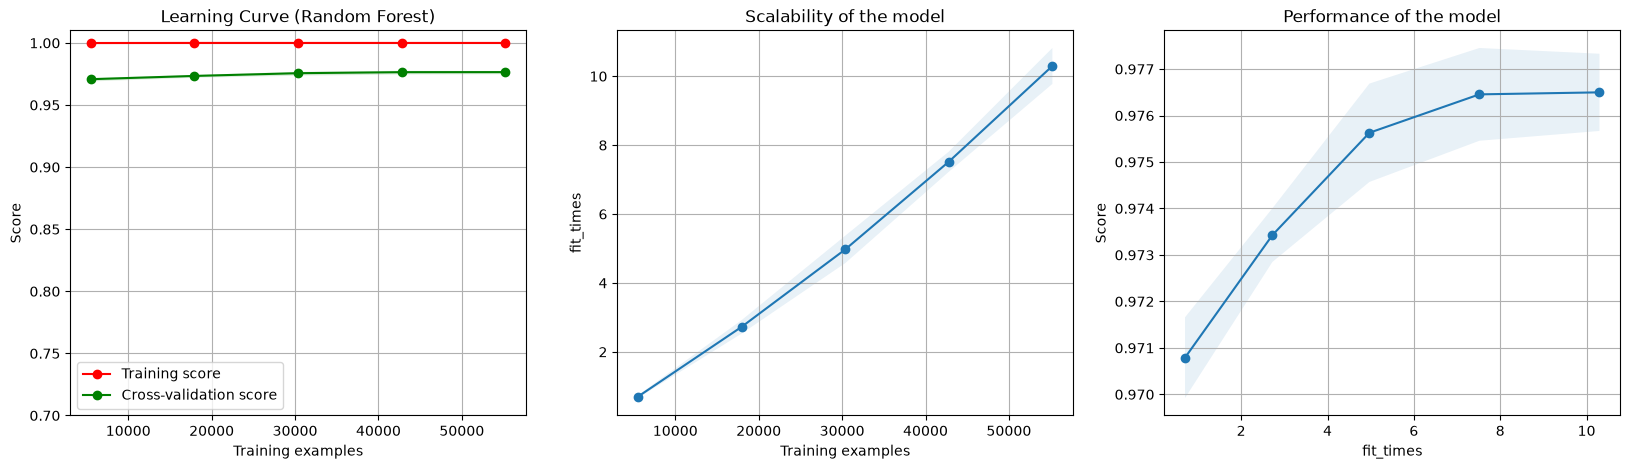

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

plot_learning_curve(random_forest_model, "Learning Curve (Random Forest)", X_train, y_train,
                    axes=axes, ylim=(0.7, 1.01), cv=cv, n_jobs=4)

plt.show()